In [3]:
from astropy.table import QTable
import matplotlib.pyplot as plt
import pandas as pd

LMC_data = QTable.read("/Users/meera/Desktop/AST-04 Data/New Stuff/LMC_photometry_original.fit")
cn_data = QTable.read("/Users/meera/Desktop/AST-04 Data/New Stuff/LMC_weakCN.fits")
cepheid_data = pd.read_csv("/Users/meera/Desktop/AST-04 Data/New Stuff/LMC_cepheid_matched_with_offset.csv")

print(LMC_data.columns)
print(cn_data.columns)
print(cepheid_data.columns)

<TableColumns names=('RAJ2000','DEJ2000','Umag','e_Umag','Bmag','e_Bmag','Vmag','e_Vmag','Imag','e_Imag','Flag')>
<TableColumns names=('ra','dec','Bmag','Imag')>
Index(['Cepheid_RA', 'Cepheid_DEC', 'Photometry_RA', 'Photometry_DEC', 'F475W',
       'F814W'],
      dtype='object')


In [6]:
LMC_f475w = LMC_data["Bmag"].value #blue
LMC_f814w = LMC_data["Imag"].value #red

cn_f475w = cn_data["Bmag"] #blue
cn_f814w = cn_data["Imag"] #red

cepheid_f475w = cepheid_data["F475W"]
cepheid_f814w = cepheid_data["F814W"]

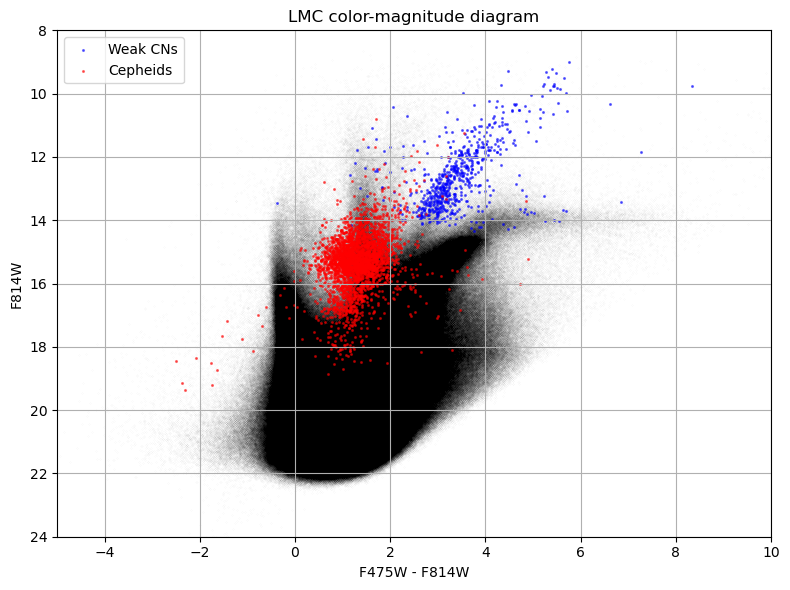

In [11]:
plt.figure(figsize = (8,6))
plt.scatter(LMC_f475w-LMC_f814w, LMC_f814w, s=0.01, alpha = 0.1, c = "black")
plt.scatter(cn_f475w-cn_f814w, cn_f814w, s=1.5, alpha = 0.5, c = "blue", label = "Weak CNs")
plt.scatter(cepheid_f475w-cepheid_f814w, cepheid_f814w, s=1.5, alpha = 0.5, c = "red", label = "Cepheids")
#plt.axhline(24, color = "red", linestyle = "--")
plt.xlim(-5,10)
plt.ylim(24, 8)
plt.legend(loc = "upper left")
plt.xlabel("F475W - F814W")
plt.ylabel("F814W")
plt.title("LMC color-magnitude diagram")
plt.grid(True)
plt.tight_layout()
plt.show()